# Neuroevolution improvement across generations

This notebook reads **only** files under `artifacts/evolution/`. It follows the recorded best candidate (the generation champion) and uses physical rollout measurements rather than the fitness score, whose formula changed during the experiment.

The primary metric is the champion's mean scored track progress per evaluation second across the five fixed simulator seeds. Dividing by the recorded rollout duration makes the 20-second generations (0-24) comparable with the 30-second generations (25-124). The secondary view shows median best-lap time alongside the number of seeds on which the champion completed at least one lap. Missing lap times remain missing (DNF), rather than being converted to zero.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from statistics import fmean, median

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [2]:
def find_evolution_dir() -> Path:
    # Support launching the notebook from the repository root or notebooks/.
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / "artifacts" / "evolution"
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not find artifacts/evolution from the current directory")


EVOLUTION_DIR = find_evolution_dir()
RESULT_PATHS = sorted(EVOLUTION_DIR.glob("generation-*/results.json"))

with (EVOLUTION_DIR / "experiment.json").open() as file:
    experiment = json.load(file)

phase_documents = []
for path in sorted(EVOLUTION_DIR.glob("phase-???.json")):
    with path.open() as file:
        phase_documents.append(json.load(file))

len(RESULT_PATHS), EVOLUTION_DIR

(125,
 PosixPath('/Users/lizziecoats/UNC/fall-26/comp-590h/formula110/artifacts/evolution'))

## Build and validate the generation-level dataset

The duration and fitness configuration for each generation come from the experiment and phase manifests. Seed-level bands below therefore reflect the same five simulator seeds, not a changing sample of tracks.

In [3]:
config_by_generation: dict[int, dict] = {}

for generation_summary in experiment["generations"]:
    config_by_generation[generation_summary["generation"]] = experiment["config"]

for phase in phase_documents:
    for generation_summary in phase.get("generations", []):
        config_by_generation[generation_summary["generation"]] = phase["config"]

records = []
observed_seed_sets = set()

for result_path in RESULT_PATHS:
    with result_path.open() as file:
        result = json.load(file)

    generation = result["generation"]
    config = config_by_generation[generation]
    champion = next(
        candidate
        for candidate in result["ranking"]
        if candidate["index"] == result["best_candidate_index"]
    )
    seed_results = champion["seed_results"]
    observed_seed_sets.add(tuple(sorted(seed_result["seed"] for seed_result in seed_results)))

    duration_s = float(config["round_seconds"])
    seed_progress_rates = [
        float(seed_result["scored_distance_m"]) / duration_s
        for seed_result in seed_results
    ]
    completed_lap_times = [
        float(seed_result["best_lap_time_s"])
        for seed_result in seed_results
        if seed_result["best_lap_time_s"] is not None
    ]

    records.append(
        {
            "generation": generation,
            "phase": result.get("phase", 0),
            "champion_checkpoint": champion["checkpoint"],
            "duration_s": duration_s,
            "mean_scored_progress_mps": fmean(seed_progress_rates),
            "min_seed_progress_mps": min(seed_progress_rates),
            "max_seed_progress_mps": max(seed_progress_rates),
            "median_best_lap_s": median(completed_lap_times) if completed_lap_times else float("nan"),
            "lap_completion_seeds": sum(seed_result["lap_count"] >= 1 for seed_result in seed_results),
            "total_laps": sum(seed_result["lap_count"] for seed_result in seed_results),
        }
    )

metrics = pd.DataFrame.from_records(records).sort_values("generation").reset_index(drop=True)
expected_generations = list(range(int(metrics["generation"].max()) + 1))
assert metrics["generation"].tolist() == expected_generations, "Generation results are missing or duplicated"
assert observed_seed_sets == {(110, 111, 112, 271, 997)}, f"Unexpected seed sets: {observed_seed_sets}"
assert metrics["duration_s"].notna().all(), "A generation is missing its recorded rollout duration"

metrics.head()

,generation,phase,champion_checkpoint,duration_s,mean_scored_progress_mps,min_seed_progress_mps,max_seed_progress_mps,median_best_lap_s,lap_completion_seeds,total_laps
0,0,0,policy-003-bc_mutated.pt,20.0,4.111139,0.037354,6.941256,NaN,0,0
1,1,0,policy-008-mutated.pt,20.0,6.789010,6.056024,7.096153,NaN,0,0
2,2,0,policy-008-mutated.pt,20.0,9.024481,7.182866,10.272027,18.416667,3,3
3,3,0,policy-008-mutated.pt,20.0,10.263760,8.344693,11.720696,16.716667,4,4
4,4,0,policy-000-elite.pt,20.0,10.263760,8.344693,11.720696,16.716667,4,4


In [4]:
def config_signature(config: dict) -> str:
    relevant = {
        "round_seconds": config["round_seconds"],
        "worst_seed_weight": config["worst_seed_weight"],
        "fitness": config["fitness"],
    }
    return json.dumps(relevant, sort_keys=True)


configuration_changes = [
    generation
    for generation in expected_generations[1:]
    if config_signature(config_by_generation[generation])
    != config_signature(config_by_generation[generation - 1])
]

duration_ranges = (
    metrics.groupby("duration_s")["generation"]
    .agg(first_generation="min", last_generation="max", count="count")
)
display(duration_ranges)
print(f"Evaluation/fitness configuration changes begin at generations: {configuration_changes}")

,first_generation,last_generation,count
duration_s,,,
20.0,0,24,25
30.0,25,124,100


Evaluation/fitness configuration changes begin at generations: [25, 50, 70]


## 1. Consistent progress metric

The solid line is the champion's mean across seeds. The shaded region is the minimum-to-maximum range across those same seeds. Higher is better. Dashed vertical lines mark changes in rollout or fitness configuration; the rate itself does not use the fitness formula.

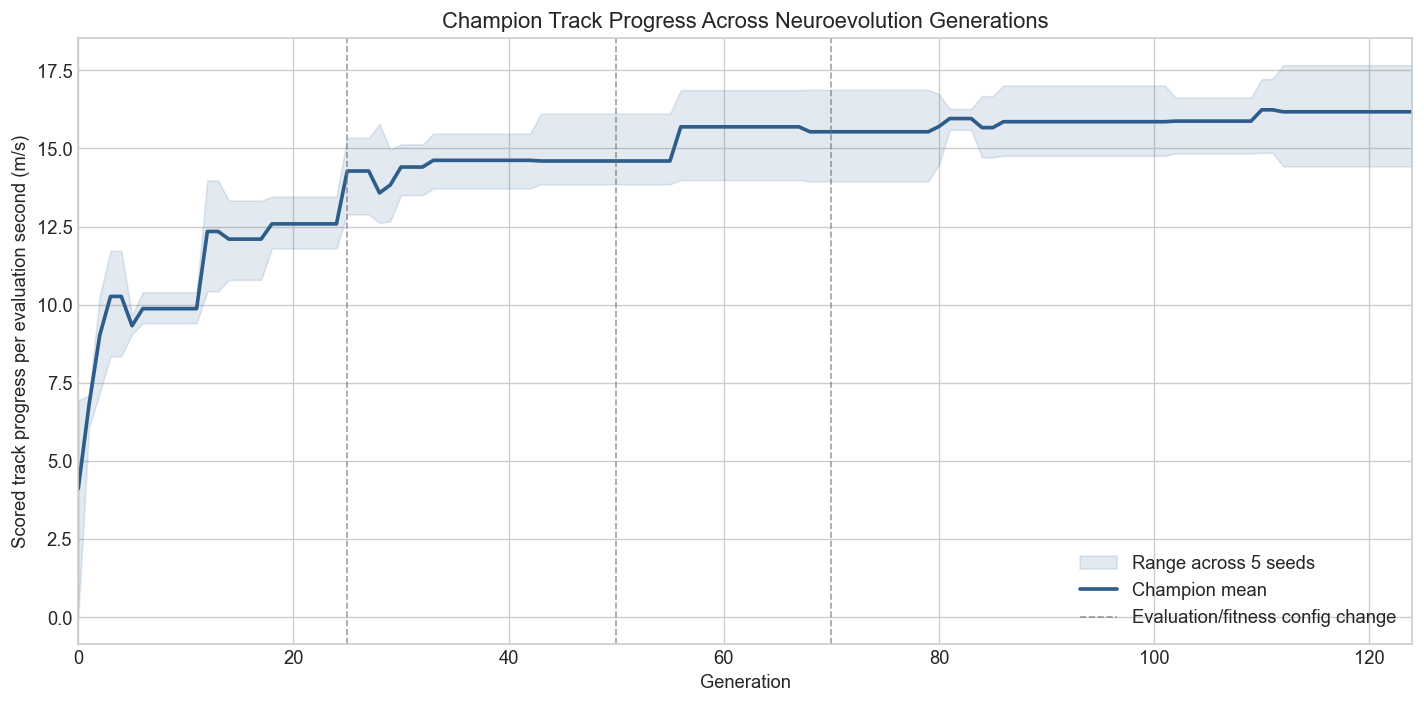

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    metrics["generation"],
    metrics["min_seed_progress_mps"],
    metrics["max_seed_progress_mps"],
    color="#4C78A8",
    alpha=0.16,
    label="Range across 5 seeds",
)
ax.plot(
    metrics["generation"],
    metrics["mean_scored_progress_mps"],
    color="#2F5D8A",
    linewidth=2.2,
    label="Champion mean",
)

for index, generation in enumerate(configuration_changes):
    ax.axvline(
        generation,
        color="#777777",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Evaluation/fitness config change" if index == 0 else None,
    )

ax.set(
    title="Champion Track Progress Across Neuroevolution Generations",
    xlabel="Generation",
    ylabel="Scored track progress per evaluation second (m/s)",
)
ax.set_xlim(metrics["generation"].min(), metrics["generation"].max())
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 2. Lap performance and completion coverage

Lap time is the median only among seeds with a completed lap, so it must be read together with completion coverage. Lower lap time is better; higher coverage is better.

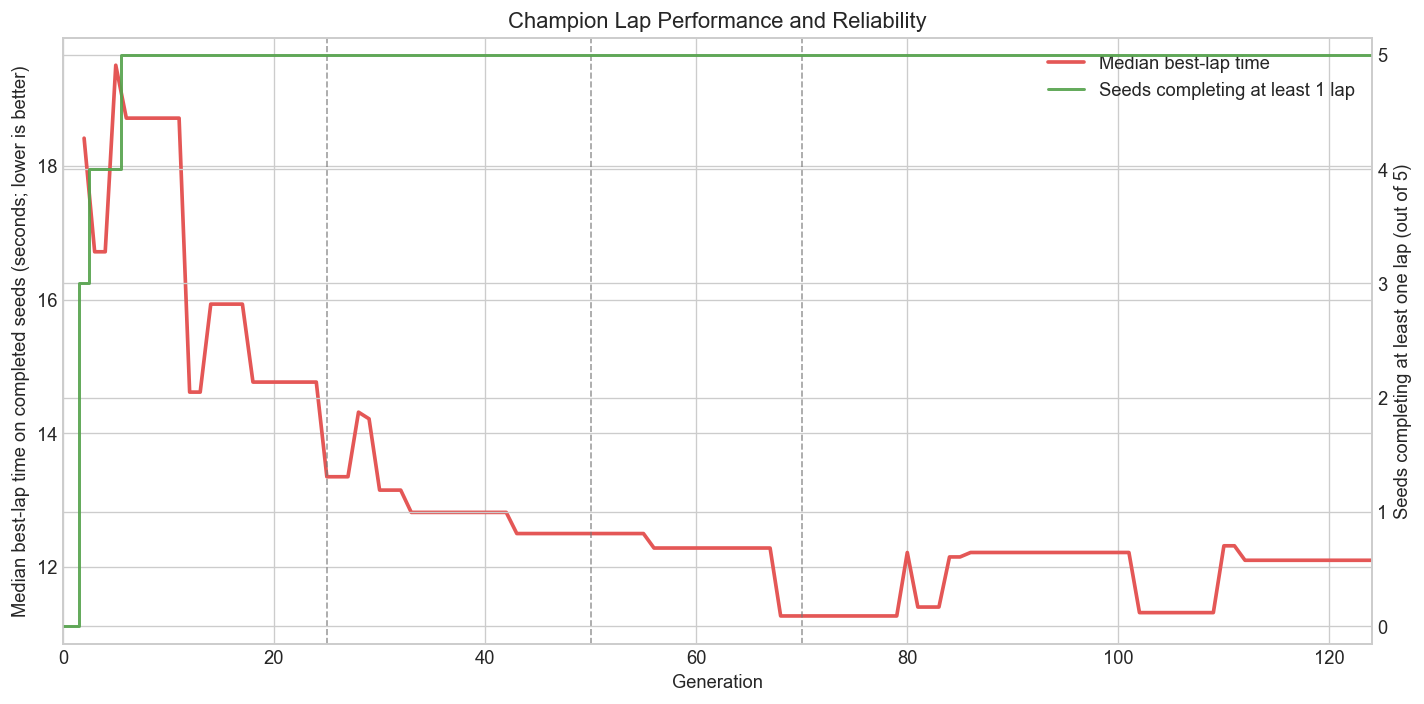

In [6]:
fig, lap_ax = plt.subplots(figsize=(12, 6))
completion_ax = lap_ax.twinx()

lap_line = lap_ax.plot(
    metrics["generation"],
    metrics["median_best_lap_s"],
    color="#E45756",
    linewidth=2.2,
    label="Median best-lap time",
)[0]
completion_line = completion_ax.step(
    metrics["generation"],
    metrics["lap_completion_seeds"],
    where="mid",
    color="#54A24B",
    linewidth=1.8,
    alpha=0.9,
    label="Seeds completing at least 1 lap",
)[0]

for generation in configuration_changes:
    lap_ax.axvline(generation, color="#777777", linestyle="--", linewidth=1, alpha=0.7)

lap_ax.set(
    title="Champion Lap Performance and Reliability",
    xlabel="Generation",
    ylabel="Median best-lap time on completed seeds (seconds; lower is better)",
)
completion_ax.set_ylabel("Seeds completing at least one lap (out of 5)")
completion_ax.set_ylim(-0.15, 5.15)
completion_ax.set_yticks(range(6))
lap_ax.set_xlim(metrics["generation"].min(), metrics["generation"].max())
lap_ax.legend(handles=[lap_line, completion_line], loc="upper right")
fig.tight_layout()
plt.show()

## 3. Controlled 30-second rescore at five-generation intervals

To remove the historical rollout-duration difference entirely, the 25 saved champions at generations 0, 5, 10, ..., 120 were freshly evaluated under the same 30-second protocol and the same five seeds. Results are stored under `artifacts/evolution/consistent-rescore-multiples-of-5/`; the earlier 13-point rescore remains preserved separately. Fitness is calculated for schema compatibility, but the chart uses only physical rollout measurements.

In [7]:
rescore_path = EVOLUTION_DIR / "consistent-rescore-multiples-of-5" / "results.json"
with rescore_path.open() as file:
    rescore_document = json.load(file)
RESCORE_GENERATIONS = tuple(item["generation"] for item in rescore_document["generations"])
print(f"Loaded controlled rescore: {rescore_path}")

Loaded controlled rescore: /Users/lizziecoats/UNC/fall-26/comp-590h/formula110/artifacts/evolution/consistent-rescore-multiples-of-5/results.json


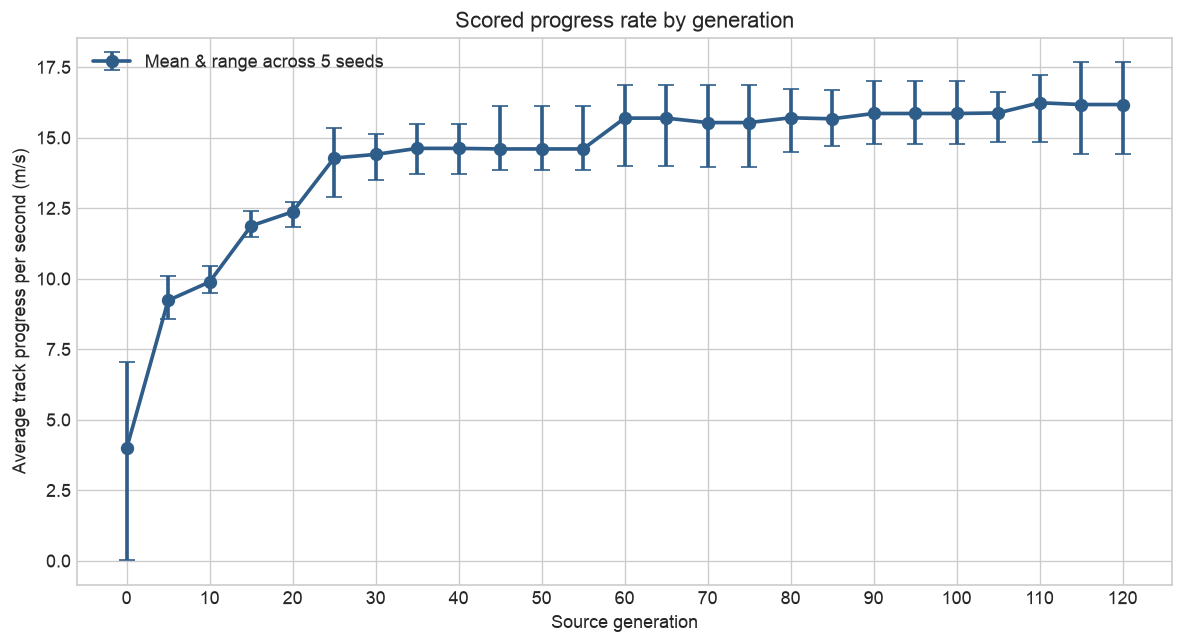

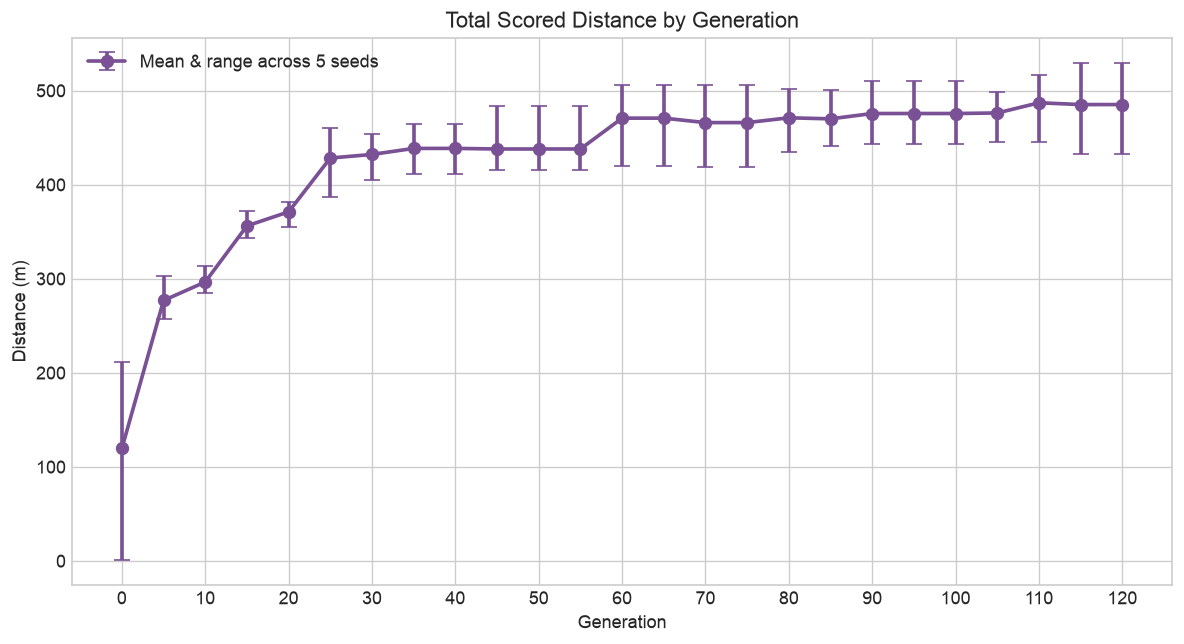

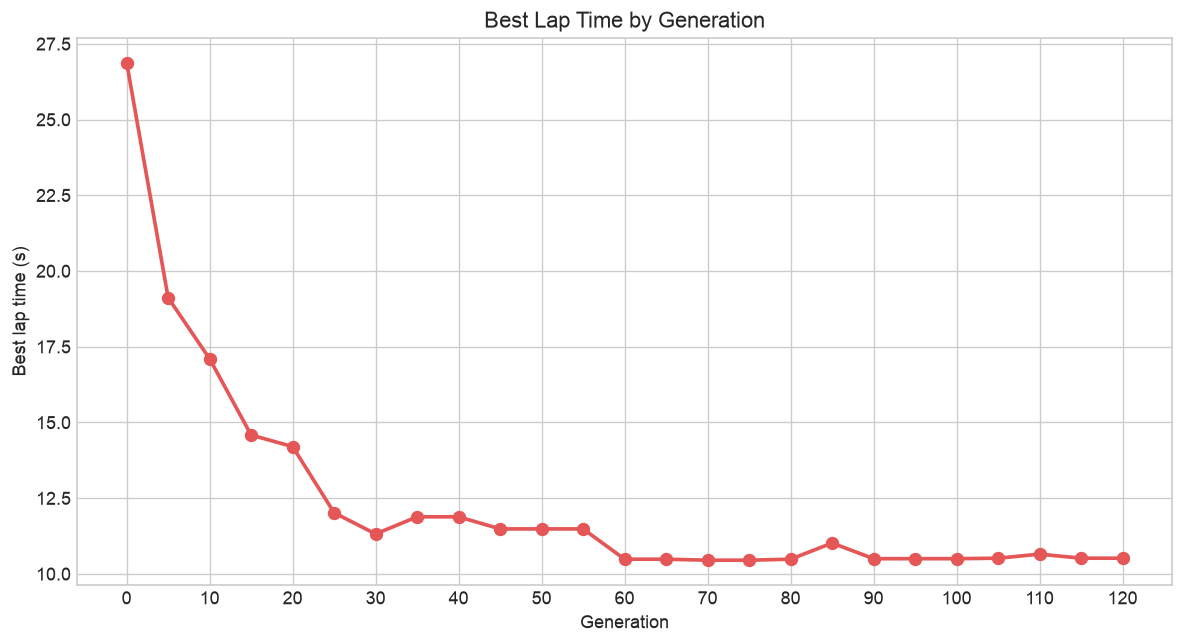

,generation,mean_scored_progress_mps,min_seed_progress_mps,max_seed_progress_mps,mean_scored_distance_m,min_seed_distance_m,max_seed_distance_m,best_lap_time_s,median_best_lap_s,lap_completion_seeds
0,0,3.984,0.025,7.042,119.534,0.747,211.266,26.883,27.383,2
1,5,9.228,8.571,10.081,276.851,257.143,302.428,19.117,19.567,5
2,10,9.886,9.500,10.461,296.571,284.999,313.841,17.100,18.717,5
3,15,11.873,11.461,12.396,356.184,343.818,371.895,14.583,15.933,5
4,20,12.370,11.835,12.721,371.096,355.038,381.638,14.200,14.767,5
5,25,14.277,12.891,15.339,428.308,386.718,460.161,12.017,13.350,5
6,30,14.404,13.507,15.129,432.120,405.196,453.862,11.317,13.150,5
7,35,14.618,13.719,15.469,438.551,411.557,464.070,11.883,12.817,5
8,40,14.618,13.719,15.469,438.551,411.557,464.070,11.883,12.817,5
9,45,14.597,13.855,16.109,437.920,415.642,483.268,11.483,12.500,5


In [41]:
rescore_records = []
for generation_result in rescore_document["generations"]:
    seed_results = generation_result["seed_results"]
    distances = [seed_result["scored_distance_m"] for seed_result in seed_results]
    rates = [
        distance / rescore_document["round_seconds"]
        for distance in distances
    ]
    lap_times = [
        seed_result["best_lap_time_s"]
        for seed_result in seed_results
        if seed_result["best_lap_time_s"] is not None
    ]
    rescore_records.append(
        {
            "generation": generation_result["generation"],
            "mean_scored_progress_mps": fmean(rates),
            "min_seed_progress_mps": min(rates),
            "max_seed_progress_mps": max(rates),
            "mean_scored_distance_m": fmean(distances),
            "min_seed_distance_m": min(distances),
            "max_seed_distance_m": max(distances),
            "best_lap_time_s": min(lap_times) if lap_times else float("nan"),
            "median_best_lap_s": median(lap_times) if lap_times else float("nan"),
            "lap_completion_seeds": sum(seed_result["lap_count"] >= 1 for seed_result in seed_results),
        }
    )

rescore_metrics = pd.DataFrame.from_records(rescore_records)
fig, ax = plt.subplots(figsize=(10, 5.5))
lower_error = rescore_metrics["mean_scored_progress_mps"] - rescore_metrics["min_seed_progress_mps"]
upper_error = rescore_metrics["max_seed_progress_mps"] - rescore_metrics["mean_scored_progress_mps"]
ax.errorbar(
    rescore_metrics["generation"],
    rescore_metrics["mean_scored_progress_mps"],
    yerr=[lower_error, upper_error],
    color="#2F5D8A", marker="o", markersize=7, linewidth=2.2, capsize=5,
    label="Mean & range across 5 seeds",
)
ax.set(
    title="Scored progress rate by generation",
    xlabel="Source generation",
    ylabel="Average track progress per second (m/s)",
)
ax.set_xticks(range(0, 121, 10))
ax.set_xticks(list(RESCORE_GENERATIONS), minor=True)
ax.legend()
fig.tight_layout()
plt.show()

fig, distance_ax = plt.subplots(figsize=(10, 5.5))
distance_lower_error = (
    rescore_metrics["mean_scored_distance_m"] - rescore_metrics["min_seed_distance_m"]
)
distance_upper_error = (
    rescore_metrics["max_seed_distance_m"] - rescore_metrics["mean_scored_distance_m"]
)
distance_ax.errorbar(
    rescore_metrics["generation"],
    rescore_metrics["mean_scored_distance_m"],
    yerr=[distance_lower_error, distance_upper_error],
    color="#7A5195", marker="o", markersize=7, linewidth=2.2, capsize=5,
    label="Mean & range across 5 seeds",
)
distance_ax.set(
    title="Total Scored Distance by Generation",
    xlabel="Generation",
    ylabel="Distance (m)",
)
distance_ax.set_xticks(range(0, 121, 10))
distance_ax.set_xticks(list(RESCORE_GENERATIONS), minor=True)
distance_ax.legend()
fig.tight_layout()
plt.show()

fig, best_lap_ax = plt.subplots(figsize=(10, 5.5))
best_lap_ax.plot(
    rescore_metrics["generation"],
    rescore_metrics["best_lap_time_s"],
    color="#E45756", marker="o", markersize=7, linewidth=2.2,
)
best_lap_ax.set(
    title="Best Lap Time by Generation",
    xlabel="Generation",
    ylabel="Best lap time (s)",
)
best_lap_ax.set_xticks(range(0, 121, 10))
best_lap_ax.set_xticks(list(RESCORE_GENERATIONS), minor=True)
fig.tight_layout()
plt.show()
display(rescore_metrics.round(3))

## Summary values

In [9]:
initial = metrics.iloc[0]
final = metrics.iloc[-1]
first_all_seeds = metrics.loc[metrics["lap_completion_seeds"] == 5].iloc[0]
best_median_lap = metrics.loc[metrics["median_best_lap_s"].idxmin()]

summary = pd.DataFrame(
    [
        {"quantity": "Initial champion mean scored progress", "generation": int(initial["generation"]), "value": f"{initial['mean_scored_progress_mps']:.2f} m/s"},
        {"quantity": "Final champion mean scored progress", "generation": int(final["generation"]), "value": f"{final['mean_scored_progress_mps']:.2f} m/s"},
        {"quantity": "First champion completing a lap on all seeds", "generation": int(first_all_seeds["generation"]), "value": f"{first_all_seeds['median_best_lap_s']:.2f} s median"},
        {"quantity": "Fastest champion median best-lap time", "generation": int(best_median_lap["generation"]), "value": f"{best_median_lap['median_best_lap_s']:.2f} s"},
        {"quantity": "Final champion median best-lap time", "generation": int(final["generation"]), "value": f"{final['median_best_lap_s']:.2f} s"},
    ]
)
display(summary.style.hide(axis="index"))
print(
    f"Final/initial scored-progress ratio: "
    f"{final['mean_scored_progress_mps'] / initial['mean_scored_progress_mps']:.2f}x"
)

quantity,generation,value
Initial champion mean scored progress,0,4.11 m/s
Final champion mean scored progress,124,16.17 m/s
First champion completing a lap on all seeds,6,18.72 s median
Fastest champion median best-lap time,68,11.27 s
Final champion median best-lap time,124,12.10 s


Final/initial scored-progress ratio: 3.93x
